# Deep Learning for Image Classification on CIFAR-10

**Student:** Zeng Yitao (12312903)

This report analyzes a series of controlled image-classification experiments on CIFAR-10 using Convolutional Neural Networks (CNNs, *Convolutional Neural Networks*). The study first examines custom CNN variants by changing core architectural factors: (i) network depth (additional convolutional layers), (ii) convolution kernel size, and (iii) pooling strategy (max pooling versus average pooling). It then extends the comparison to representative standard architectures, including AlexNet, VGG, Inception, and ResNet.

All experiments are executed through a unified script-based pipeline (`src/train.py`) and a centralized configuration file (`configs/experiments.yaml`). This design improves reproducibility by ensuring that data handling, optimization logic, evaluation metrics, and logging are managed consistently across runs.

To maintain fairness, each comparison are interpreted under matched settings whenever possible (for example: dataset split policy, optimizer, batch size, and learning-rate schedule). This notebook therefore includes a configuration-consistency check before presenting comparative conclusions.

This notebook auto-discovers run artifacts under `output/`, aggregates metrics, verifies configuration consistency, and generates analysis-ready figures and tables.

### Brief Introduction to CIFAR-10

CIFAR-10 is a small, classic, and extremely popular benchmark dataset for multi-class image classification. It contains 10 object categories (for example, airplane, automobile, bird, cat, deer, dog, frog, horse, ship, and truck), with color images at a resolution of 32 x 32 pixels,which isn't so high, so it could enable fast training.

CIFAR-10 is appropriate for this assignment for three reasons:

1. It is computationally feasible for iterative architecture and hyperparameter exploration.
2. It is sufficiently challenging to expose meaningful differences between model designs.
3. It is widely used in the literature, which makes performance interpretation more standardized.

### Notebook Scope

A. Setup and metric definitions

B. Main quantitative result table

C. Combined and per-run plots

D. Interpretations

E. Limitations and reporting checklist



In [60]:
from pathlib import Path
import json
import yaml

import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 120)

OUTPUT_ROOT = Path("output")
assert OUTPUT_ROOT.exists(), "Expected output/ directory in repo root."

In [61]:
def discover_run_dirs(output_root: Path):
    """Find all run directories that contain metrics/history/config artifacts."""
    run_dirs = []
    for metrics_path in sorted(output_root.glob("*/*/metrics.json")):
        run_dir = metrics_path.parent
        required = ["metrics.json", "history.json", "config_resolved.yaml"]
        if all((run_dir / name).exists() for name in required):
            run_dirs.append(run_dir)
    return run_dirs


def load_json(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def load_yaml(path: Path):
    with open(path, "r", encoding="utf-8") as f:
        return yaml.safe_load(f)


run_dirs = discover_run_dirs(OUTPUT_ROOT)
print(f"Discovered {len(run_dirs)} run(s).")
for i, rd in enumerate(run_dirs, 1):
    print(f"{i:>2}. {rd}")

Discovered 8 run(s).
 1. output/alexnet/04-23-14-59-06_alexnet
 2. output/baseline/04-23-15-00-51_baseline
 3. output/inception_v3/04-23-14-57-46_inception_v3
 4. output/resnet18/04-23-14-56-32_resnet18
 5. output/run_a_deeper/04-23-15-10-34_run_a_deeper
 6. output/run_b_kernel5/04-23-15-02-43_run_b_kernel5
 7. output/run_c_avgpool/04-23-13-56-18_run_c_avgpool
 8. output/vgg11_bn/04-23-14-58-55_vgg11_bn


In [62]:
records = []
histories = {}
configs = {}

for run_dir in run_dirs:
    metrics = load_json(run_dir / "metrics.json")
    history = load_json(run_dir / "history.json")
    config = load_yaml(run_dir / "config_resolved.yaml")

    run_id = f"{run_dir.parent.name}/{run_dir.name}"
    histories[run_id] = history
    configs[run_id] = config

    record = {
        "run_id": run_id,
        "experiment_id": config.get("experiment_id"),
        "name": metrics.get("name"),
        "model_family": metrics.get("model_family"),
        "architecture_note": metrics.get("architecture_note"),
        "train_time_sec": metrics.get("train_time_sec"),
        "best_epoch": metrics.get("best_epoch"),
        "early_stopped": metrics.get("early_stopped"),
        "train_accuracy": metrics.get("train_accuracy"),
        "test_accuracy": metrics.get("test_accuracy"),
        "test_recall_macro": metrics.get("test_recall_macro"),
        "test_f1_macro": metrics.get("test_f1_macro"),
        "best_monitor": metrics.get("best_monitor"),
        "best_monitor_value": metrics.get("best_monitor_value"),
    }
    records.append(record)

summary_df = pd.DataFrame(records)
summary_df = summary_df.sort_values(["test_f1_macro", "test_accuracy"], ascending=False).reset_index(drop=True)
summary_df

,run_id,experiment_id,name,model_family,architecture_note,train_time_sec,best_epoch,early_stopped,train_accuracy,test_accuracy,test_recall_macro,test_f1_macro,best_monitor,best_monitor_value
0,resnet18/04-23-14-56-32_resnet18,resnet18,ResNet18_CIFAR,ResNet,resnet18 with CIFAR conv stem,241.747000,32,True,0.931917,0.8254,0.8254,0.825678,val_loss,0.570686
1,inception_v3/04-23-14-57-46_inception_v3,inception_v3,InceptionV3_CIFAR,Inception,"inception_v3 (aux disabled), resized input",813.792063,41,True,0.938667,0.7984,0.7984,0.799249,val_loss,0.583742
2,vgg11_bn/04-23-14-58-55_vgg11_bn,vgg11_bn,VGG11_BN_CIFAR,VGG,torchvision vgg11_bn adapted classifier,254.896328,34,True,0.873500,0.7882,0.7882,0.790784,val_loss,0.649888
3,alexnet/04-23-14-59-06_alexnet,alexnet,AlexNet_CIFAR,AlexNet,CIFAR-adapted AlexNet-style network,500.669438,43,True,0.866917,0.7514,0.7514,0.752097,val_loss,0.761795
4,run_a_deeper/04-23-15-10-34_run_a_deeper,run_a_deeper,Run_A_DeeperConv,CustomCNN,"3 conv, 3x3 kernels, 2 MaxPool",244.319187,54,True,0.851083,0.7509,0.7509,0.749937,val_loss,0.727225
5,baseline/04-23-15-00-51_baseline,baseline,Baseline,CustomCNN,"2 conv, 3x3 kernels, 2 MaxPool",422.488844,80,True,0.821167,0.7468,0.7468,0.746364,val_loss,0.761265
6,run_b_kernel5/04-23-15-02-43_run_b_kernel5,run_b_kernel5,Run_B_Kernel5,CustomCNN,"2 conv, 5x5 kernels, 2 MaxPool",318.674281,84,False,0.802500,0.7314,0.7314,0.729903,val_loss,0.799385
7,run_c_avgpool/04-23-13-56-18_run_c_avgpool,run_c_avgpool,Run_C_AvgPool,CustomCNN,"2 conv, 3x3 kernels, 2 AvgPool",630.870000,73,True,0.797833,0.7188,0.7188,0.717151,val_loss,0.818719


## Main Result Table

Primary ranking metric: **test macro F1** (F1-Score, macro average).

Secondary metrics shown together: test accuracy and test macro recall.

Training time is also included for performance-vs-cost interpretation.

In [63]:
display_cols = [
    "run_id", "experiment_id", "model_family", "architecture_note",
    "test_f1_macro", "test_accuracy", "test_recall_macro",
    "train_accuracy", "best_epoch", "early_stopped", "train_time_sec"
]

report_df = summary_df[display_cols].copy()
report_df["train_time_min"] = report_df["train_time_sec"] / 60.0
report_df = report_df.drop(columns=["train_time_sec"])
report_df = report_df.rename(columns={
    "test_f1_macro": "test_f1_macro (primary)",
    "test_accuracy": "test_accuracy",
    "test_recall_macro": "test_recall_macro",
    "train_accuracy": "train_accuracy",
    "train_time_min": "train_time_min"
})
report_df

,run_id,experiment_id,model_family,architecture_note,test_f1_macro (primary),test_accuracy,test_recall_macro,train_accuracy,best_epoch,early_stopped,train_time_min
0,resnet18/04-23-14-56-32_resnet18,resnet18,ResNet,resnet18 with CIFAR conv stem,0.825678,0.8254,0.8254,0.931917,32,True,4.029117
1,inception_v3/04-23-14-57-46_inception_v3,inception_v3,Inception,"inception_v3 (aux disabled), resized input",0.799249,0.7984,0.7984,0.938667,41,True,13.563201
2,vgg11_bn/04-23-14-58-55_vgg11_bn,vgg11_bn,VGG,torchvision vgg11_bn adapted classifier,0.790784,0.7882,0.7882,0.873500,34,True,4.248272
3,alexnet/04-23-14-59-06_alexnet,alexnet,AlexNet,CIFAR-adapted AlexNet-style network,0.752097,0.7514,0.7514,0.866917,43,True,8.344491
4,run_a_deeper/04-23-15-10-34_run_a_deeper,run_a_deeper,CustomCNN,"3 conv, 3x3 kernels, 2 MaxPool",0.749937,0.7509,0.7509,0.851083,54,True,4.071986
5,baseline/04-23-15-00-51_baseline,baseline,CustomCNN,"2 conv, 3x3 kernels, 2 MaxPool",0.746364,0.7468,0.7468,0.821167,80,True,7.041481
6,run_b_kernel5/04-23-15-02-43_run_b_kernel5,run_b_kernel5,CustomCNN,"2 conv, 5x5 kernels, 2 MaxPool",0.729903,0.7314,0.7314,0.802500,84,False,5.311238
7,run_c_avgpool/04-23-13-56-18_run_c_avgpool,run_c_avgpool,CustomCNN,"2 conv, 3x3 kernels, 2 AvgPool",0.717151,0.7188,0.7188,0.797833,73,True,10.514500


### Definitions and Formulas for the 4 Headline Metrics

The table columns in this notebook include four frequently used metrics: `test_f1_macro (primary)`, `test_accuracy`, `test_recall_macro`, and `train_accuracy`.

#### 1) Test Accuracy

**Meaning:** the proportion of correctly classified samples on the **test set**.

$$
\mathrm{test\_accuracy} = \frac{N_{\mathrm{correct,test}}}{N_{\mathrm{test}}}
$$

#### 2) Test Recall Macro (Macro Recall)

**Meaning:** first compute recall for each class, then average all classes equally.

For class $c$:
$$
\mathrm{Recall}_c = \frac{TP_c}{TP_c + FN_c}
$$

Macro recall across $K$ classes:
$$
\mathrm{test\_recall\_macro} = \frac{1}{K}\sum_{c=1}^{K}\mathrm{Recall}_c
$$

Here, $TP$ is true positive and $FN$ is false negative.

#### 3) Test F1 Macro (F1-Score, Macro Average)

**Meaning:** for each class, compute precision and recall, then compute per-class F1, and finally average F1 equally across classes.

For class $c$:
$$
\mathrm{Precision}_c = \frac{TP_c}{TP_c + FP_c}, \qquad
\mathrm{Recall}_c = \frac{TP_c}{TP_c + FN_c}
$$

$$
F1_c = \frac{2\,\mathrm{Precision}_c\,\mathrm{Recall}_c}{\mathrm{Precision}_c + \mathrm{Recall}_c}
$$

$$
\mathrm{test\_f1\_macro} = \frac{1}{K}\sum_{c=1}^{K} F1_c
$$

Here, $FP$ is false positive.

#### 4) Train Accuracy

**Meaning:** the proportion of correctly classified samples on the **training set** (evaluated after training using the saved best checkpoint in this pipeline).

$$
\mathrm{train\_accuracy} = \frac{N_{\mathrm{correct,train}}}{N_{\mathrm{train}}}
$$


## Combined Curves (All Runs Together)

Each metric is overlaid across runs to compare dynamics directly.

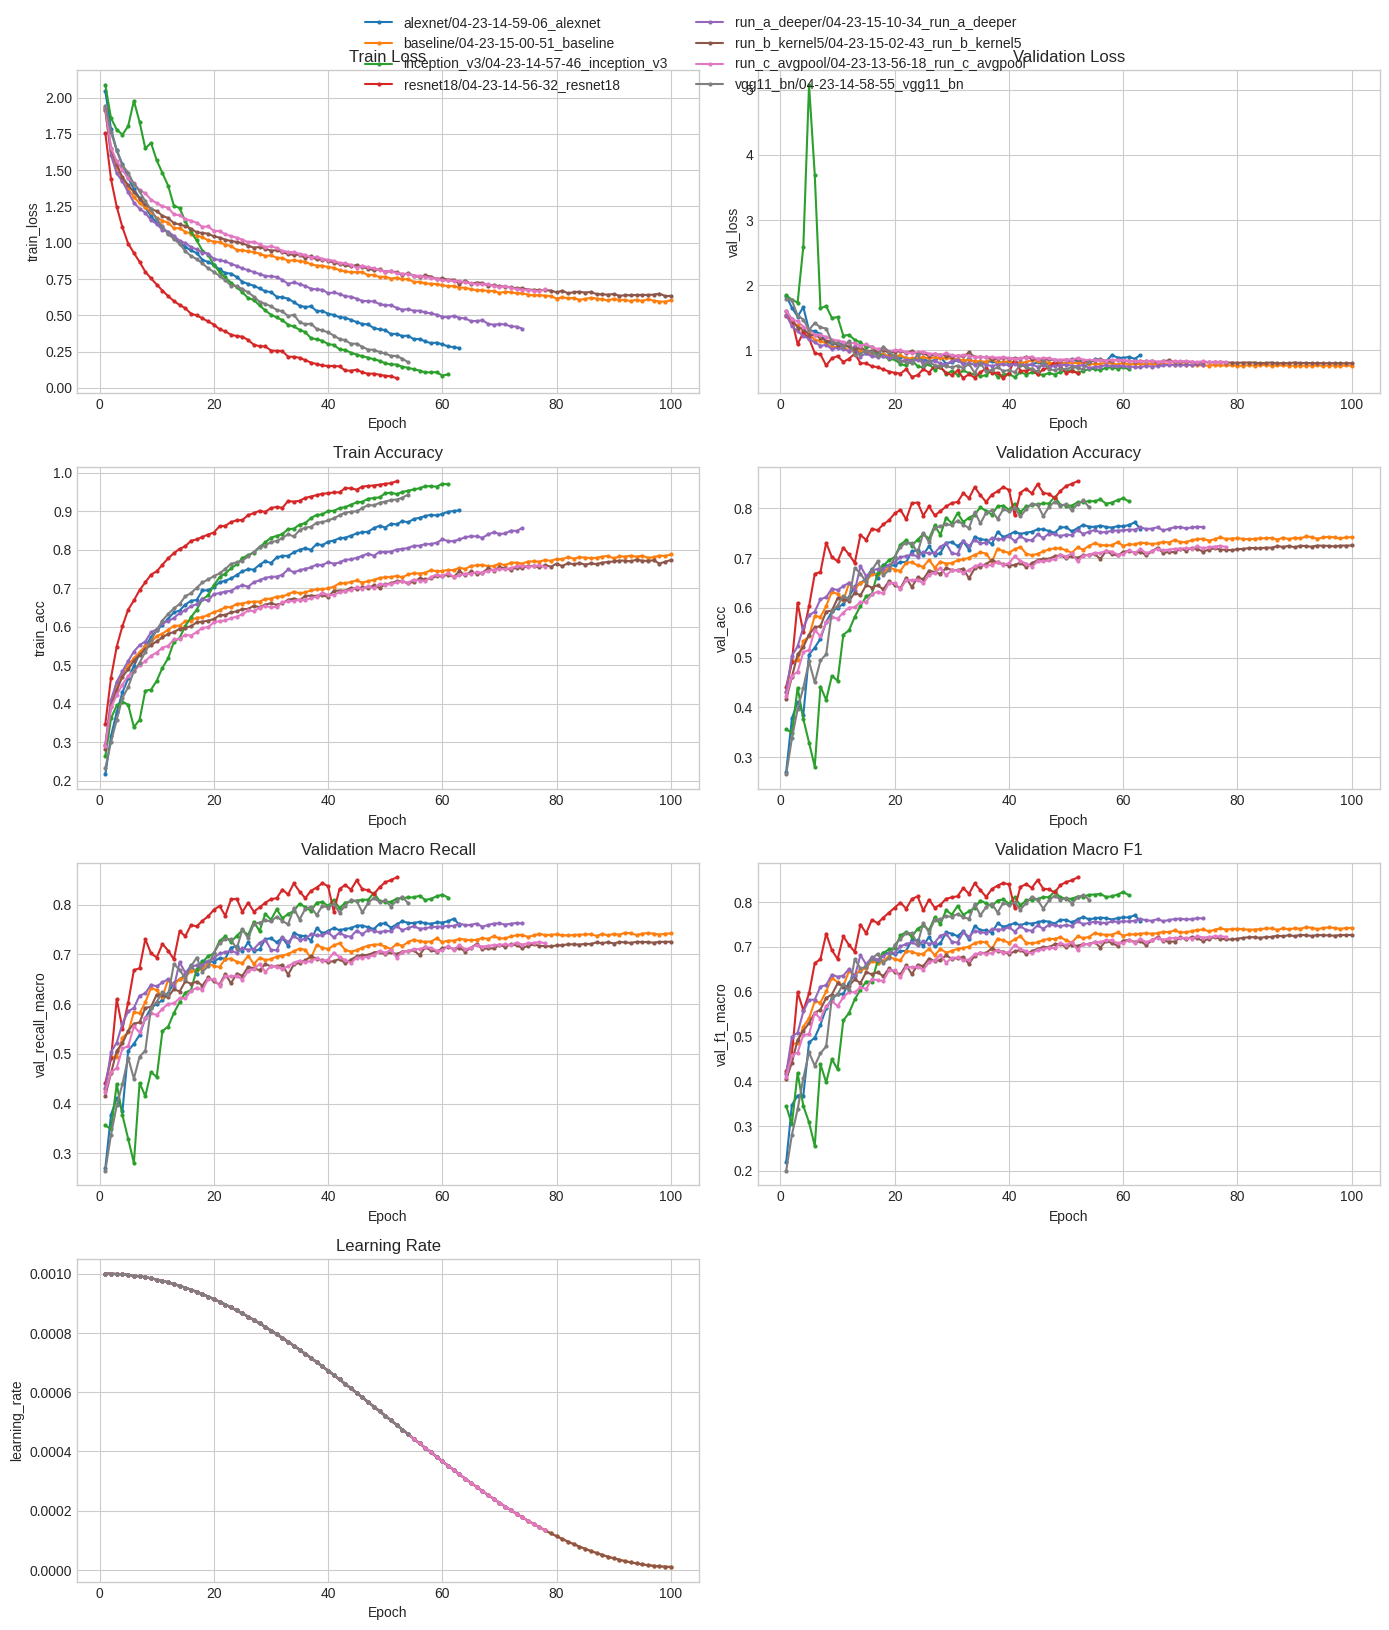

In [64]:
metrics_for_curves = [
    ("train_loss", "Train Loss"),
    ("val_loss", "Validation Loss"),
    ("train_acc", "Train Accuracy"),
    ("val_acc", "Validation Accuracy"),
    ("val_recall_macro", "Validation Macro Recall"),
    ("val_f1_macro", "Validation Macro F1"),
    ("learning_rate", "Learning Rate"),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
axes = axes.ravel()

for ax, (metric_key, metric_title) in zip(axes, metrics_for_curves):
    for run_id, hist in histories.items():
        values = hist.get(metric_key)
        if values is None:
            continue
        x = range(1, len(values) + 1)
        ax.plot(x, values, marker="o", markersize=2, linewidth=1.5, label=run_id)
    ax.set_title(metric_title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric_key)

axes[-1].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

## Per-Run Curves (Printed Separately)

The same metrics are shown one run at a time for easier readability when many runs exist.

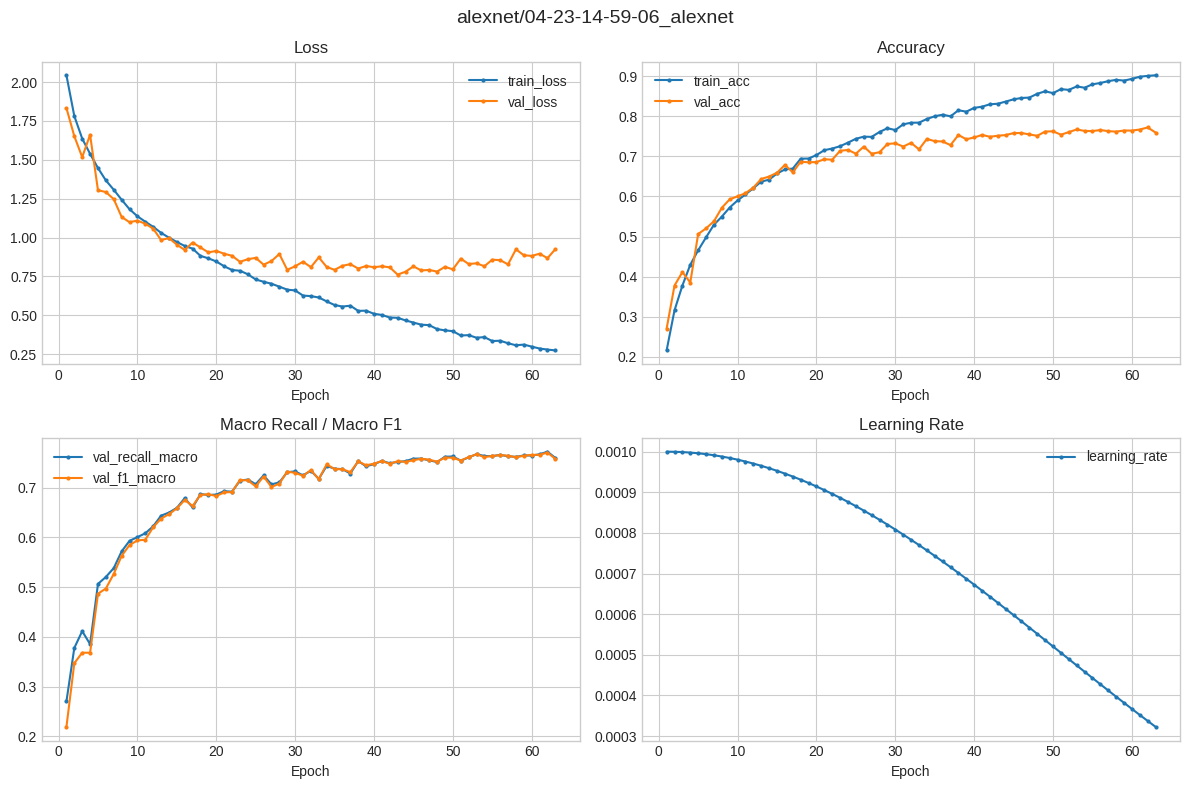

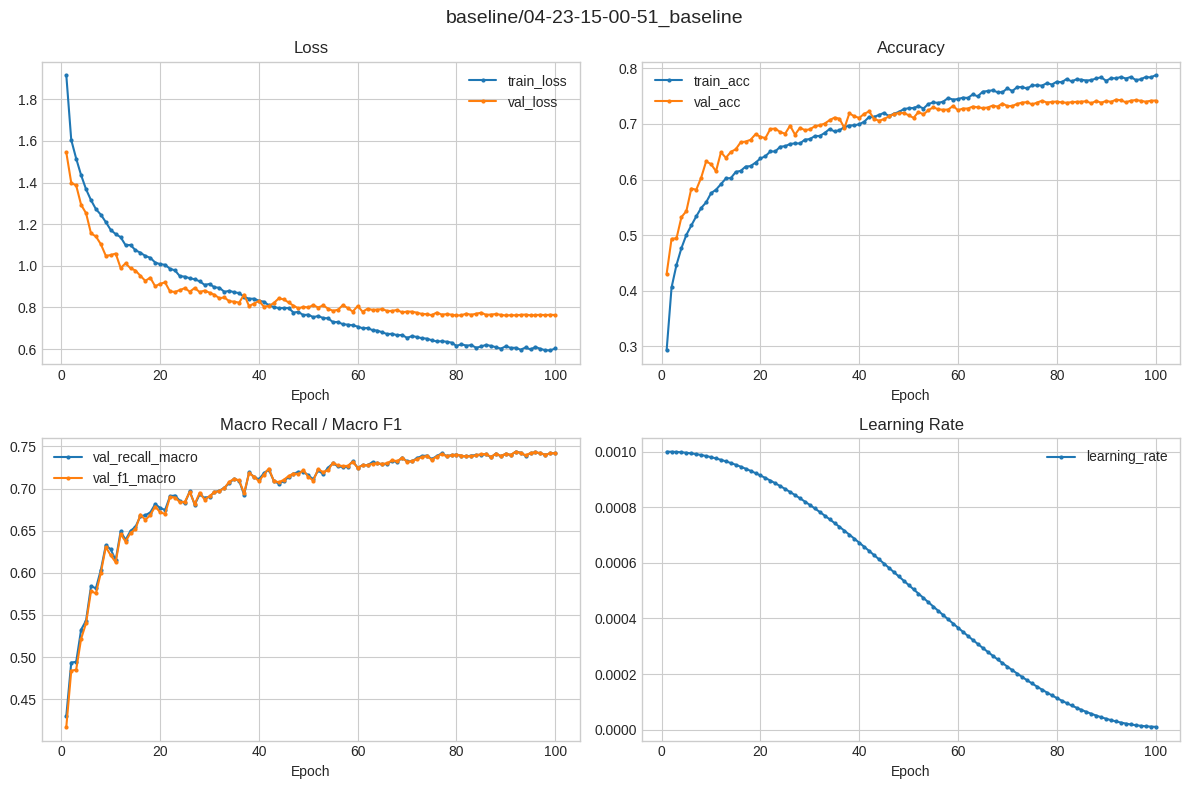

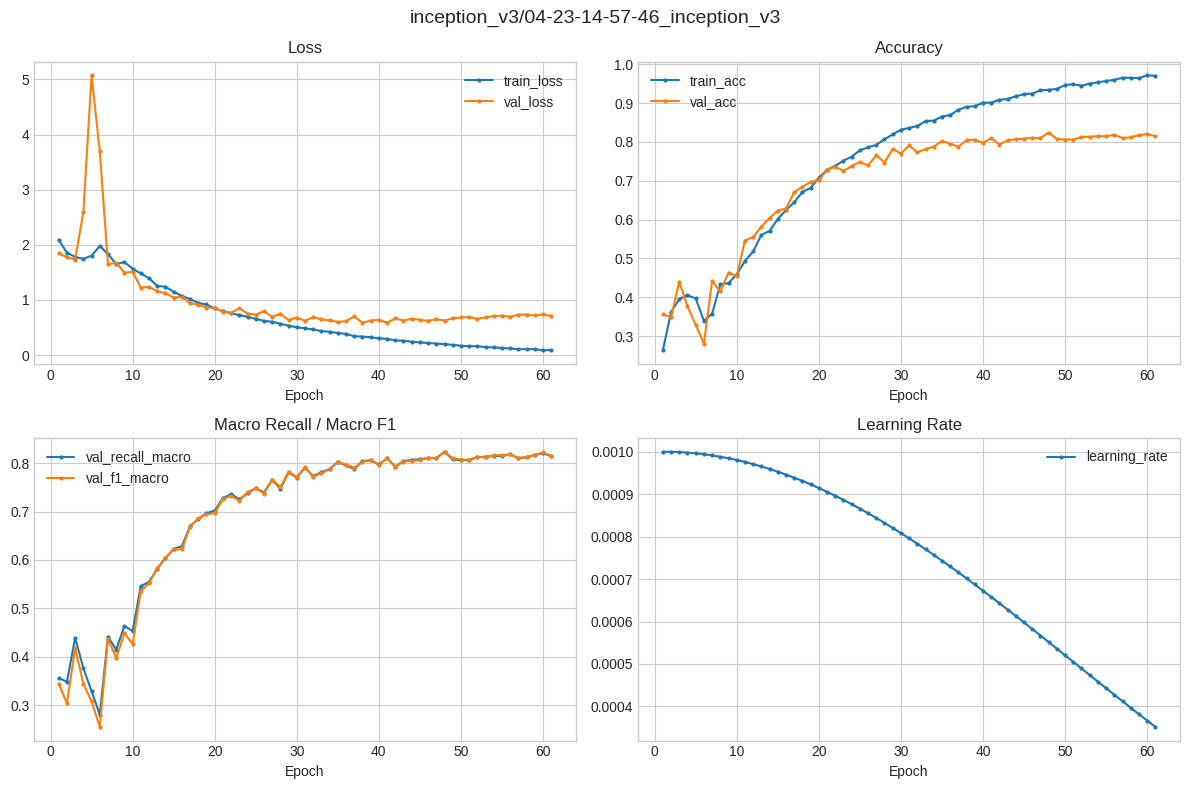

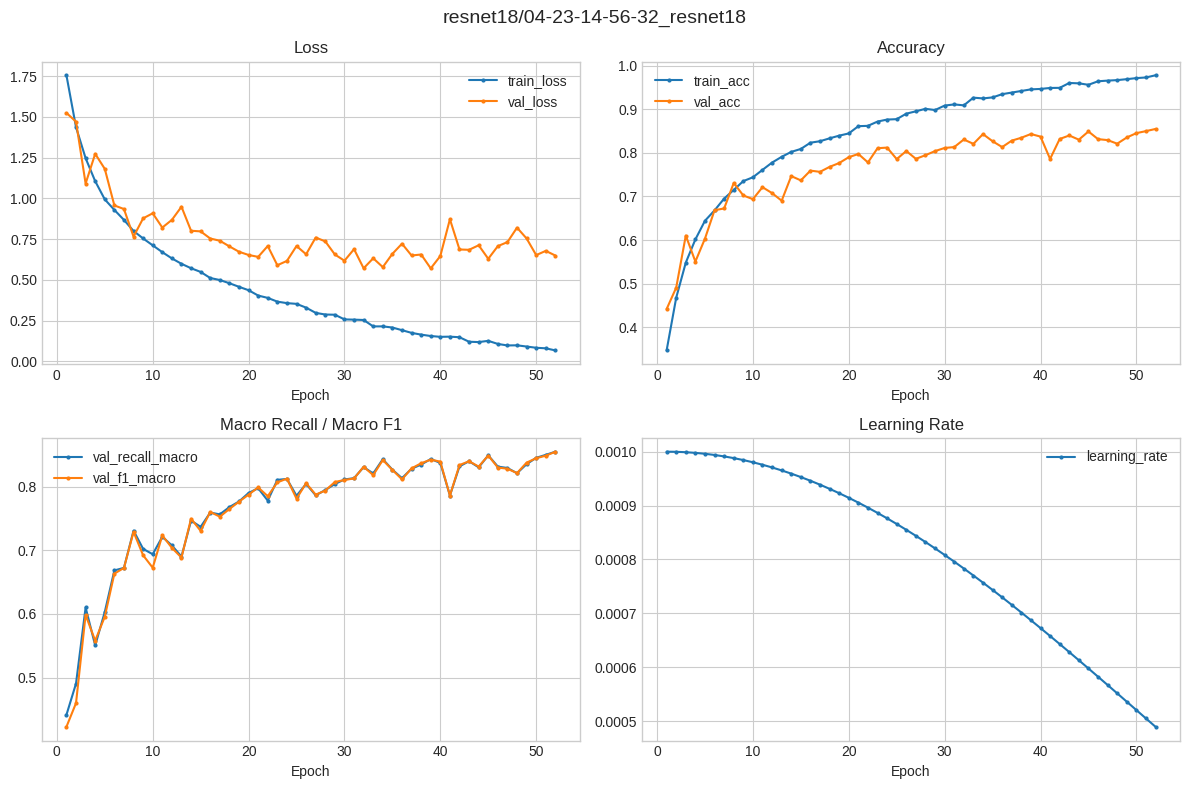

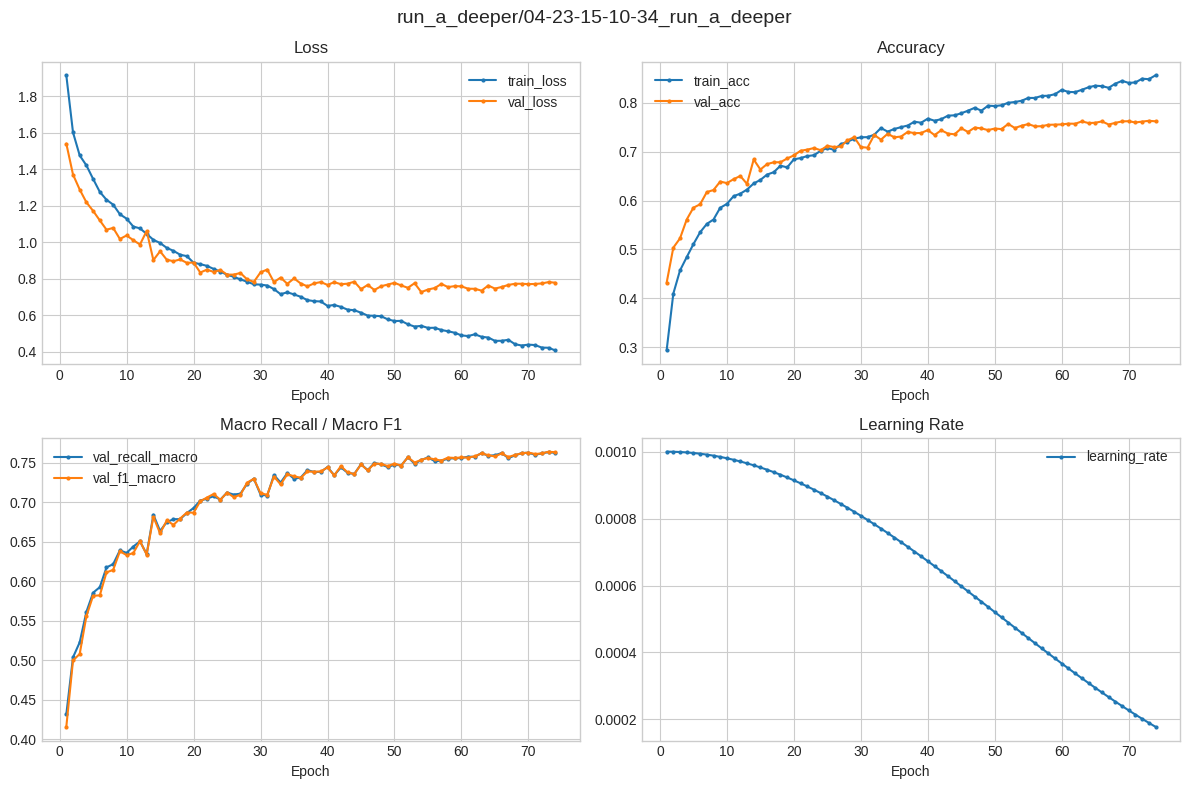

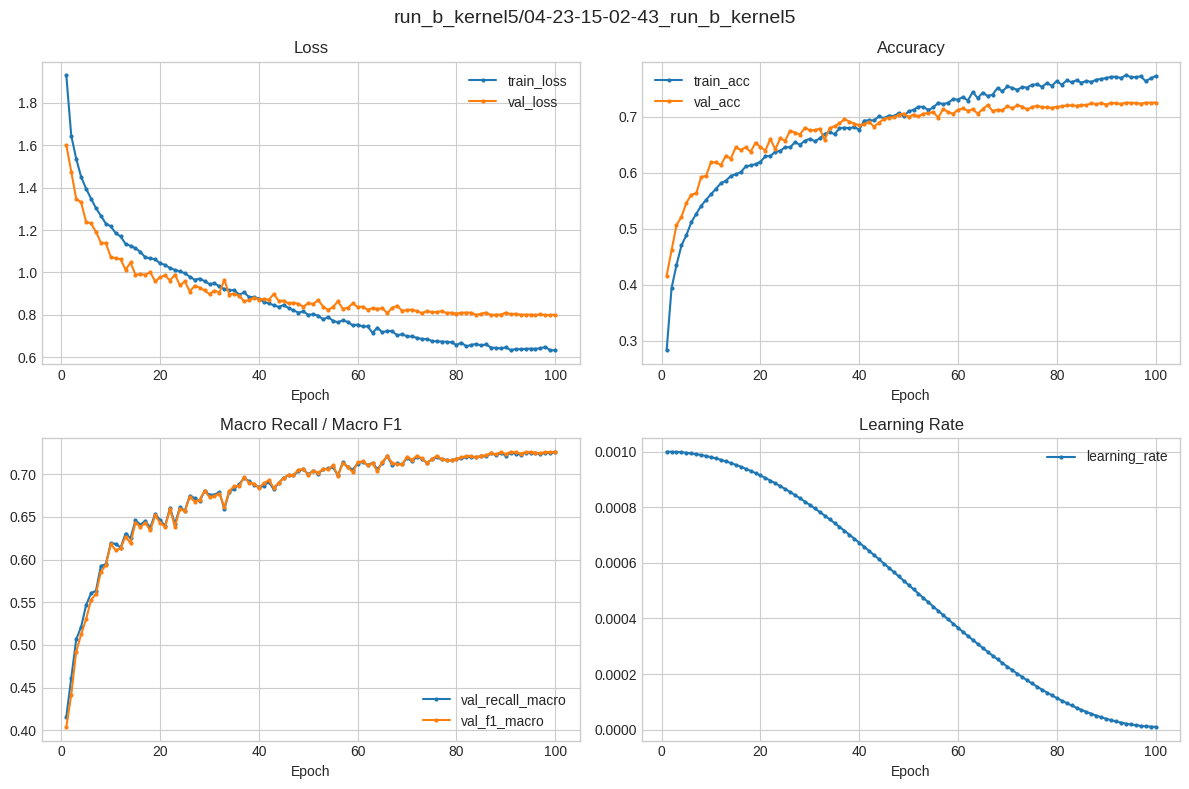

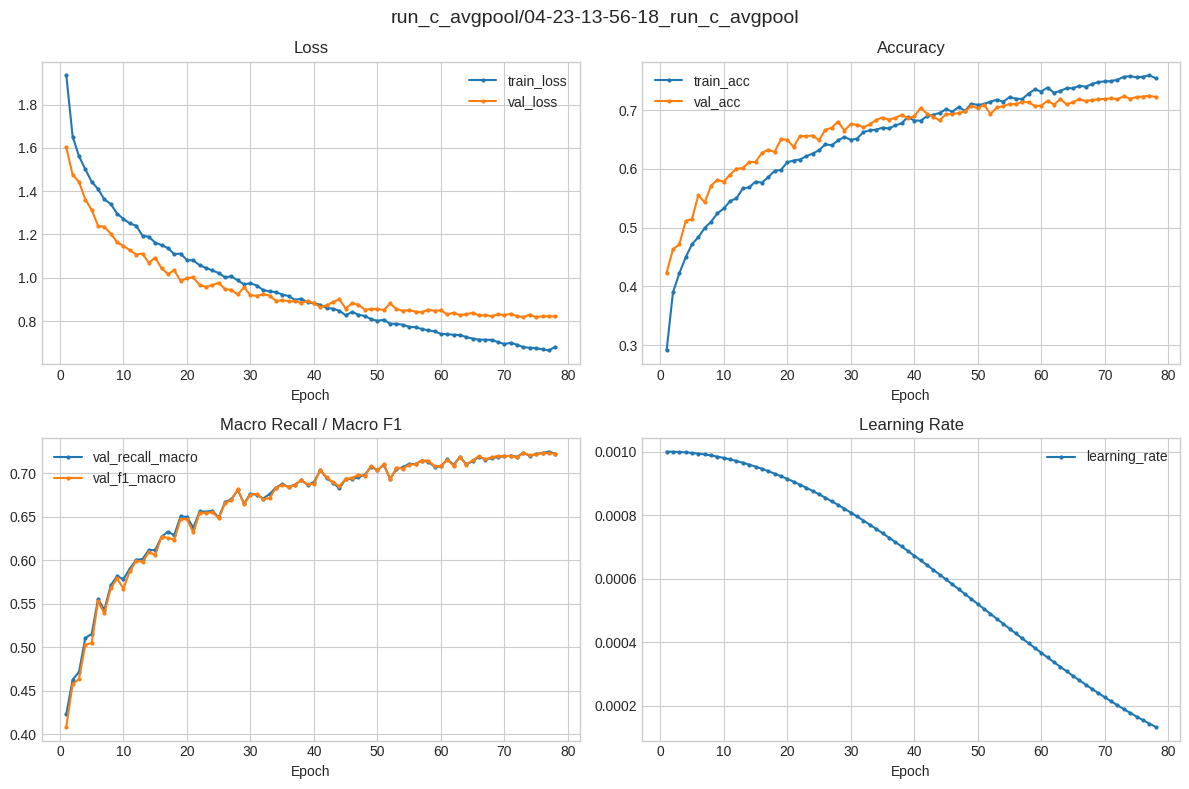

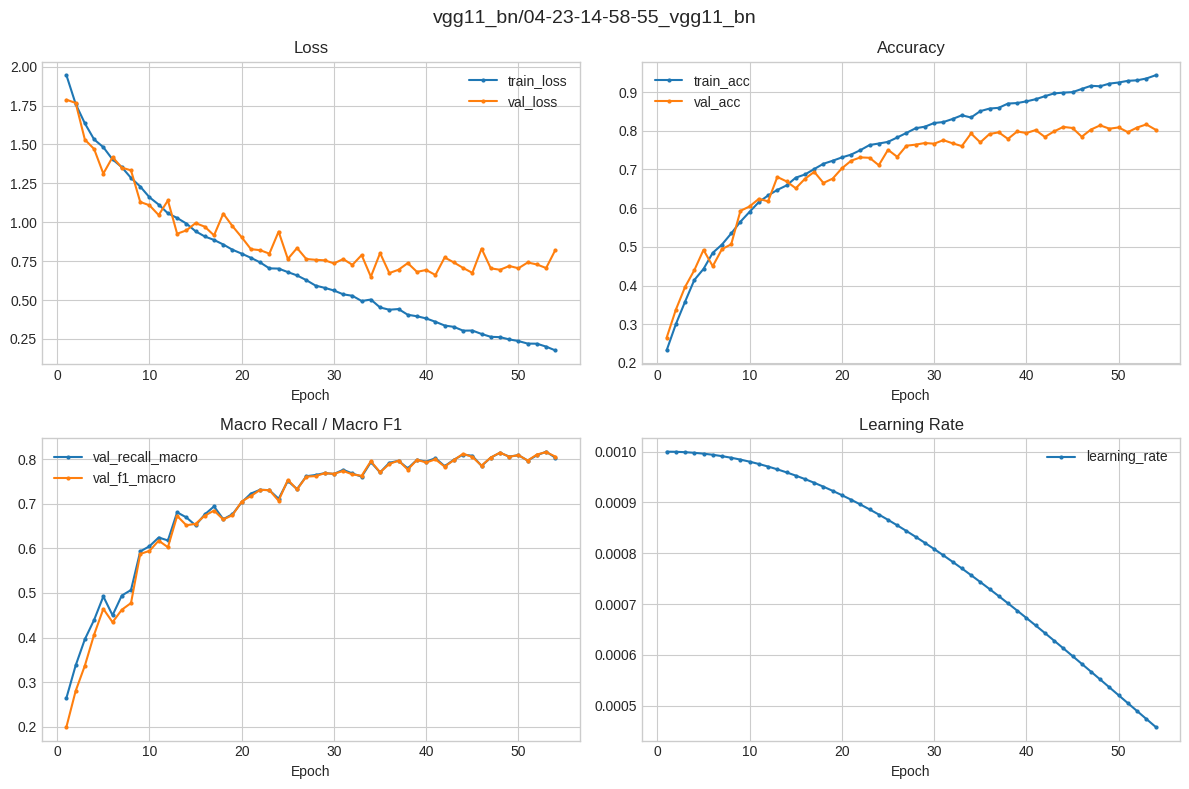

In [65]:
per_run_metrics = [
    ("train_loss", "val_loss", "Loss"),
    ("train_acc", "val_acc", "Accuracy"),
    ("val_recall_macro", "val_f1_macro", "Macro Recall / Macro F1"),
    ("learning_rate", None, "Learning Rate"),
]

for run_id, hist in histories.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.ravel()
    fig.suptitle(run_id, fontsize=14)

    for ax, (k1, k2, title) in zip(axes, per_run_metrics):
        v1 = hist.get(k1, [])
        x1 = range(1, len(v1) + 1)
        ax.plot(x1, v1, marker="o", markersize=2, linewidth=1.5, label=k1)

        if k2 is not None and k2 in hist:
            v2 = hist.get(k2, [])
            x2 = range(1, len(v2) + 1)
            ax.plot(x2, v2, marker="o", markersize=2, linewidth=1.5, label=k2)

        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.legend()

    fig.tight_layout()
    plt.show()

As could be seen, all of them are trained to a good point where train_acc beats val_acc and all losses converges.

## Final Metric Comparison (Bar Charts)

Primary metric first: test macro F1. Secondary: test accuracy and test macro recall.

A time-cost chart is included to show performance vs training cost.

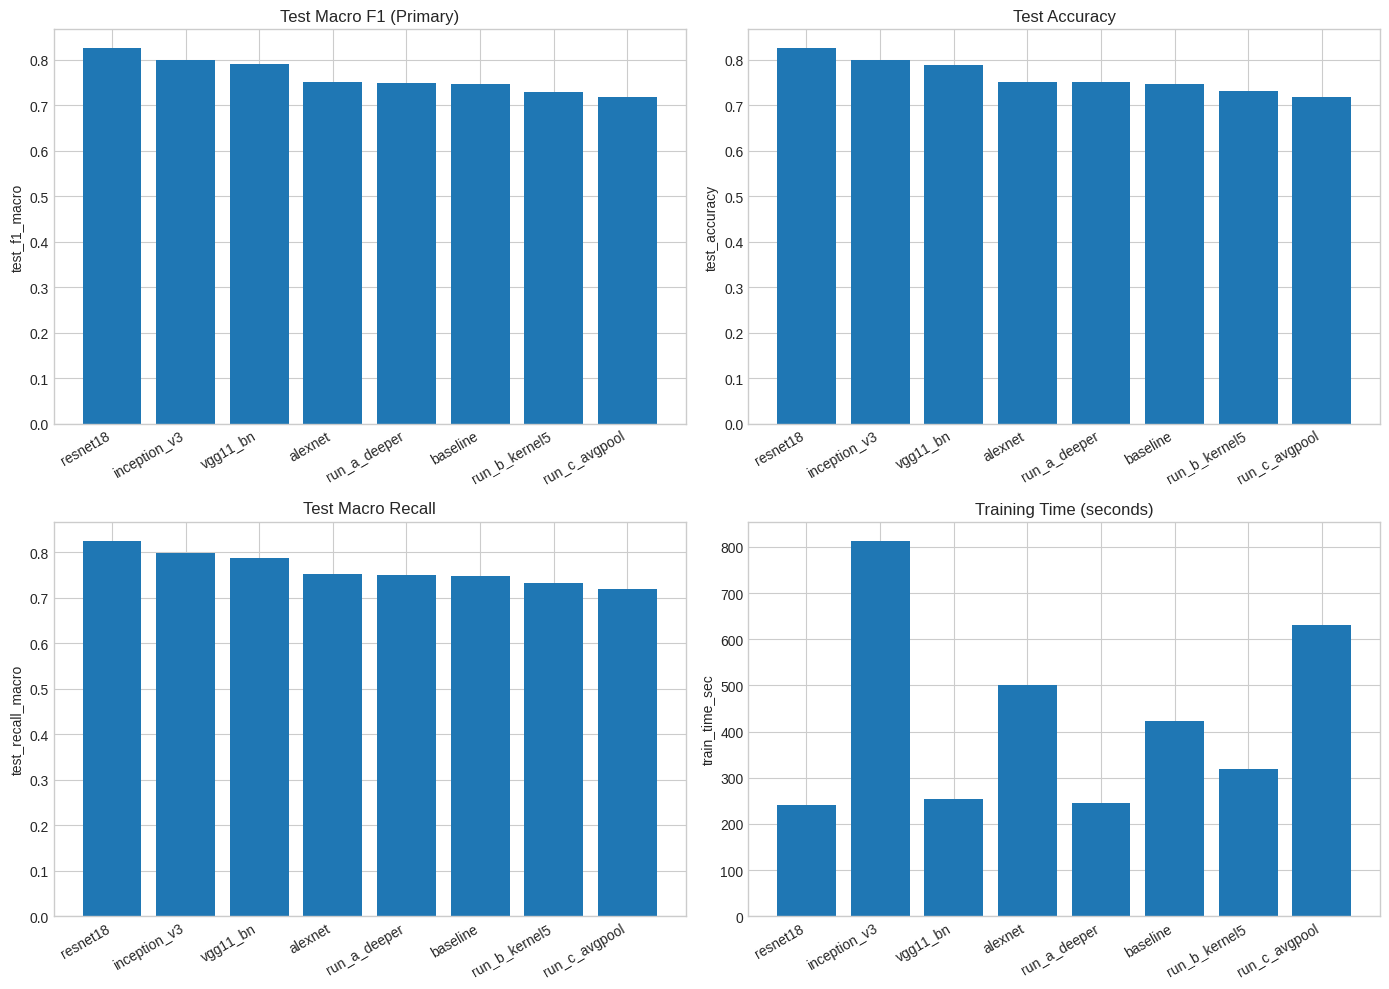

In [66]:
plot_df = summary_df.copy()
plot_df = plot_df.sort_values("test_f1_macro", ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

bar_specs = [
    ("test_f1_macro", "Test Macro F1 (Primary)"),
    ("test_accuracy", "Test Accuracy"),
    ("test_recall_macro", "Test Macro Recall"),
    ("train_time_sec", "Training Time (seconds)"),
]

x_labels = plot_df["experiment_id"].tolist()
x_pos = range(len(x_labels))

for ax, (col, title) in zip(axes, bar_specs):
    ax.bar(x_pos, plot_df[col].tolist())
    ax.set_title(title)
    ax.set_ylabel(col)
    ax.set_xticks(list(x_pos))
    ax.set_xticklabels(x_labels, rotation=30, ha="right")

fig.tight_layout()
plt.show()

### Summary
From the above we could see that resnet performed the best, however, even though when the patience was 20 in the early-stop, resnet still stopped too early due to its fluctuating feature.The cause might be that resnet optimizes too fast, leading to over-correction.

The sequence is also aligned with the model's capacity, resnet > inception > vgg > alexnet. Note that for inception we resized the pictures to 75*75 since inception is used for large size pictures. 

The baseline, however, performed better than when adding the kernel and switching from max pooling to avg pooling. The reason why avg pooling loss to max pooling may be that the graphs are too small(32*32), max pooling could preserve salient features.